# NCXplain — Mutable Generator Costs
## Applied to 6-bus, IEEE 14-bus and IEEE 39-bus

**Structure**
- Section 0 — Imports and helpers
- Section 1 — Dataset loading
- Section 2 — Factual UC solve and foil candidate scan
- Section 3 — NCXplain for each grid with plots
- Section 4 — Cross-grid comparison


## 0 · Imports and helpers

In [1]:
import os, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import gurobipy as gp
from gurobipy import GRB

# ── Gurobi licence ────────────────────────────────────────────────────
#os.environ["GRB_LICENSE_FILE"] = r"C:\\Users\\PC3\\gurobi.lic"
os.environ["GRB_LICENSE_FILE"] = r"C:\\Users\\tomas\\Desktop\\gurobi.lic"

import uc_pipeline, uc_master_relax_4b, uc_data_loader
importlib.reload(uc_pipeline)
importlib.reload(uc_data_loader)

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
)
from uc_data_loader import quick_setup
from b3_ncxplain import run_ncxplain_uc

warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


### Foil helpers and scanning utilities

In [2]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ── Foil helpers ──────────────────────────────────────────────────────────
def _as_list(x):
    if x is None: return []
    return list(x) if isinstance(x,(list,tuple,set)) else [x]

def _get_var(var, names):
    for n in names:
        if isinstance(var,dict) and n in var: return var[n]
        if hasattr(var,n): return getattr(var,n)
    raise KeyError(f"Could not find any of {names}")

def foil_force_on(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u","U"])
        for t in times:
            m.addConstr(u[g,t]==1, name=f"foil_on_g{g}_t{t}")
    return _f

def foil_force_off(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u","U"])
        for t in times:
            m.addConstr(u[g,t]==0, name=f"foil_off_g{g}_t{t}")
    return _f

def compose_foils(*foils):
    foils = [f for f in foils if f is not None]
    if not foils: return None
    def _all(m, var, *a, **k):
        for f in foils: f(m,var,*a,**k)
    return _all


# ── Foil candidate scanner ────────────────────────────────────────────────
def scan_foil_candidates(data, idx, cvec, solF, zF,
                         window_size, per_bus_neutrality,
                         u_init, p_init, on_t, off_t,
                         min_gap=100, max_gap=1e7, block_len_range=(2,4)):
    nG = len(data.gens)
    T  = int(data.T)
    factual_obj = float(np.dot(cvec, zF))
    candidates  = []
    print(f"Scanning foil candidates  (factual obj={factual_obj:.0f})")
    print(f"  g  times             gap    type  verdict")
    print("  " + "-"*55)
    def get_blocks(hrs):
        blocks = []
        if hrs:
            s = p = hrs[0]
            for t in hrs[1:]:
                if t != p+1: blocks.append((s,p)); s=t
                p=t
            blocks.append((s,p))
        return blocks
    for g in range(nG):
        gen = data.gens[g]
        if gen.UT > 1 or gen.DT > 1: continue
        uF_g    = solF["u"][g]
        on_hrs  = [t for t in range(T) if int(round(uF_g[t]))==1]
        off_hrs = [t for t in range(T) if int(round(uF_g[t]))==0]
        for (t0,t1), ftype in ([(b,"ON") for b in get_blocks(off_hrs)] +
                                [(b,"OFF") for b in get_blocks(on_hrs)]):
            for L in range(block_len_range[0], block_len_range[1]+1):
                if t0+L-1 > t1: continue
                times = list(range(t0, t0+L))
                foil  = foil_force_on(g,times) if ftype=="ON" else foil_force_off(g,times)
                _, solT, zT = solve_uc_with_cost_4b(
                    data=data, idx=idx, cvec=cvec,
                    window_size=window_size, per_bus_neutrality=per_bus_neutrality,
                    u_init=u_init, p_init=p_init,
                    on_time_init=on_t, off_time_init=off_t,
                    extra_constr_fn=foil, output_flag=0,
                )
                if solT is None: continue
                gap = float(np.dot(cvec,zT)) - factual_obj
                ok  = min_gap < gap < max_gap
                verdict = "good" if ok else ("trivial" if gap<=min_gap else "too large")
                print(f"  g={g}  t={str(times):>15}  {gap:>8.0f}  {ftype:>4}  {verdict}")
                if ok: candidates.append((gap, g, times, ftype))
    candidates.sort()
    if candidates:
        print(f"\n  Best: G{candidates[0][1]} {candidates[0][3]} "
              f"t={candidates[0][2]} gap={candidates[0][0]:.0f}")
    else:
        print("\n  No good candidates found.")
    return candidates


# ── Colour palette ────────────────────────────────────────────────────────
TECH_COLORS = ["#73726c","#378ADD","#BA7517","#7F77DD","#1D9E75",
               "#D85A30","#639922","#5DCAA5","#EF9F27","#E24B4A"]


# ── Commitment heatmap ────────────────────────────────────────────────────
def plot_commitment_heatmap(solF, solCF, DATA,
                             foil_g=None, foil_times=None, foil_type=None,
                             label=""):
    """
    Side-by-side commitment heatmap.
    solF  = sol_factual   (original costs, no foil)
    solCF = sol_foil      (original costs + foil constraint)
    Orange borders mark cells changed by the counterfactual.
    """
    nG = len(DATA.gens)
    T  = int(DATA.T)
    uF  = np.round(solF["u"]).astype(int)
    uCF = np.round(solCF["u"]).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, nG*0.65+2)), sharey=True)
    fig.suptitle(f"Unit Commitment — Factual vs Counterfactual   [{label}]",
                 fontsize=12, fontweight="bold")

    color_on   = plt.cm.Blues(0.55)
    color_off  = (0.94, 0.94, 0.97, 1.0)
    changed_ec = "#E86E00"

    for ax, u_mat, title, tcol in [
        (axes[0], uF,  "Factual",        "royalblue"),
        (axes[1], uCF, "Counterfactual", "crimson"),
    ]:
        ax.set_facecolor("white")
        for g in range(nG):
            for t in range(T):
                fc = color_on if u_mat[g,t] else color_off
                rect = mpatches.FancyBboxPatch(
                    (t-0.48, nG-g-1-0.48), 0.96, 0.96,
                    boxstyle="square,pad=0", lw=0.3,
                    edgecolor="#cccccc", facecolor=fc)
                ax.add_patch(rect)
                # Orange border for changed cells
                if uCF[g,t] != uF[g,t]:
                    brd = mpatches.FancyBboxPatch(
                        (t-0.48, nG-g-1-0.48), 0.96, 0.96,
                        boxstyle="square,pad=0", lw=2.2,
                        edgecolor=changed_ec, facecolor="none")
                    ax.add_patch(brd)
        # On-hour count on right
        for g in range(nG):
            ax.text(T+0.15, nG-g-1, f"{u_mat[g].sum()}h",
                    va="center", ha="left", fontsize=8, color="#444")
        ax.set_xlim(-0.5, T+2)
        ax.set_ylim(-0.5, nG-0.5)
        ax.set_yticks(range(nG))
        ax.set_yticklabels([f"Gen {nG-1-g}" for g in range(nG)], fontsize=8)
        ax.set_xlabel("Hour"); ax.set_xticks(range(0, T, 2))
        ax.set_title(title, fontsize=11, fontweight="bold", color=tcol)
        for sp in ax.spines.values(): sp.set_visible(False)
        ax.grid(False)

    patch_on  = mpatches.Patch(color=color_on,  label="ON")
    patch_off = mpatches.Patch(color=color_off, label="OFF",
                                edgecolor="#aaa", lw=0.5)
    patch_chg = mpatches.Patch(color="none", edgecolor=changed_ec,
                                lw=2, label="Changed by CE")
    axes[1].legend(handles=[patch_on, patch_off, patch_chg],
                   loc="lower right", fontsize=8, framealpha=0.9)

    n_changed = int(np.sum(uCF != uF))
    n_on2off  = int(np.sum((uF==1)&(uCF==0)))
    n_off2on  = int(np.sum((uF==0)&(uCF==1)))
    fig.text(0.5, 0.01,
             f"{n_changed} commitment cell(s) changed  "
             f"({n_off2on} OFF→ON, {n_on2off} ON→OFF)",
             ha="center", fontsize=9, color="#555")
    plt.tight_layout(rect=[0,0.04,1,0.96])
    plt.show()


# ── Full NCXplain results figure ─────────────────────────────────────────
def plot_ncxplain_results(DATA, out, label="",
                           foil_g=None, foil_times=None, foil_type=None):
    if out is None:
        print(f"[{label}] out is None"); return
    status = str(out.get("status","")).upper()
    if status != "OPTIMAL":
        print(f"[{label}] status={out.get('status')} — nothing to plot"); return

    solF    = out.get("sol_factual")
    # sol_foil = UC under original costs + foil constraint (the CE commitment)
    # sol_opt  = UC under new costs, no foil (the new optimal)
    solFoil = out.get("sol_foil")
    solOpt  = out.get("sol_opt")
    if solF is None:
        print(f"[{label}] missing sol_factual"); return

    nG  = len(DATA.gens)
    nR  = len(DATA.rens)
    T   = int(DATA.T)
    hrs = np.arange(T)
    foil_desc = (f"G{foil_g} {foil_type} at t={foil_times}"
                 if foil_g is not None else "")

    # ── Figure 1: dispatch + curtailment + shedding + cost changes ───────
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"NCXplain — {label}   [foil: {foil_desc}]",
                 fontsize=13, fontweight="bold")
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.30)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, :])

    # Dispatch panels — factual and foil (CE commitment)
    sol_cf_dispatch = solFoil if solFoil is not None else solOpt
    for ax, sol, title in [(ax1, solF, "Factual dispatch"),
                            (ax2, sol_cf_dispatch, "Counterfactual dispatch")]:
        if sol is None: ax.set_title(f"{title} (N/A)"); continue
        bottom = np.zeros(T)
        for g in range(nG):
            col = TECH_COLORS[g % len(TECH_COLORS)]
            ax.fill_between(hrs, bottom, bottom+sol["p"][g],
                            color=col, alpha=0.75, label=f"G{g}", step="mid")
            bottom += sol["p"][g]
        # Add renewable injection on top
        if nR > 0 and "curt" in sol:
            ren_inj = np.array([
                sum(float(DATA.rens[r].avail[t]) - sol["curt"][r,t]
                    for r in range(nR))
                for t in range(T)
            ])
            ax.fill_between(hrs, bottom, bottom+ren_inj,
                            color="#1D9E75", alpha=0.5, label="Renewable", step="mid")
            bottom += ren_inj
        # Total production line
        ax.plot(hrs, bottom, color="orange", lw=1.8, ls="-",
                label="Total production", zorder=5)
        ax.plot(hrs, DATA.demand.sum(axis=0), "k--", lw=1.5, label="Demand")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Hour"); ax.set_ylabel("MW")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=4, loc="upper left")

    # Curtailment
    curtF  = solF["curt"].sum(axis=0)  if nR>0 and "curt" in solF  else np.zeros(T)
    curtCF = (sol_cf_dispatch["curt"].sum(axis=0)
              if sol_cf_dispatch is not None and nR>0 and "curt" in sol_cf_dispatch
              else np.zeros(T))
    ax3.bar(hrs-0.2, curtF,  0.38, color="#D85A30", alpha=0.8, label="Factual")
    ax3.bar(hrs+0.2, curtCF, 0.38, color="#378ADD", alpha=0.8, label="Counterfactual")
    ax3.set_title("Curtailment per hour (MWh)", fontsize=10)
    ax3.set_xlabel("Hour"); ax3.set_ylabel("MWh")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis="y")
    ax3.text(0.98,0.97, f"F:{curtF.sum():.1f}  CF:{curtCF.sum():.1f} MWh",
             transform=ax3.transAxes, ha="right", va="top", fontsize=8)

    # Shedding
    shedF  = solF["shed"].sum(axis=0)  if "shed" in solF  else np.zeros(T)
    shedCF = (sol_cf_dispatch["shed"].sum(axis=0)
              if sol_cf_dispatch is not None and "shed" in sol_cf_dispatch
              else np.zeros(T))
    ax4.bar(hrs-0.2, shedF,  0.38, color="#BA7517", alpha=0.8, label="Factual")
    ax4.bar(hrs+0.2, shedCF, 0.38, color="#7F77DD", alpha=0.8, label="Counterfactual")
    ax4.set_title("Load shedding per hour (MWh)", fontsize=10)
    ax4.set_xlabel("Hour"); ax4.set_ylabel("MWh")
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis="y")
    ax4.text(0.98,0.97, f"F:{shedF.sum():.1f}  CF:{shedCF.sum():.1f} MWh",
             transform=ax4.transAxes, ha="right", va="top", fontsize=8)

    # Cost changes — capped to ±50% of original (no-load fix)
    fuel_orig = np.array([g.fuel_cost    for g in DATA.gens])
    nlod_orig = np.array([g.no_load_cost for g in DATA.gens])
    su_orig   = np.array([g.SU_cost      for g in DATA.gens])
    sd_orig   = np.array([g.SD_cost      for g in DATA.gens])
    fuel_new  = np.array(out.get("fuel_cost_new",    fuel_orig))
    nlod_new  = np.array(out.get("no_load_cost_new", nlod_orig))
    su_new    = np.array(out.get("su_cost_new",       su_orig))
    sd_new    = np.array(out.get("sd_cost_new",       sd_orig))

    x = np.arange(nG); w = 0.20
    df = fuel_new - fuel_orig
    dn = nlod_new - nlod_orig
    ds = su_new   - su_orig
    dd = sd_new   - sd_orig
    ax5.bar(x-1.5*w, df, w, color="#D85A30", alpha=0.8, label="Fuel Δ ($/MWh)")
    ax5.bar(x-0.5*w, dn, w, color="#378ADD", alpha=0.8, label="No-load Δ ($/h)")
    ax5.bar(x+0.5*w, ds, w, color="#1D9E75", alpha=0.8, label="SU cost Δ ($)")
    ax5.bar(x+1.5*w, dd, w, color="#BA7517", alpha=0.8, label="SD cost Δ ($)")
    ax5.axhline(0, color="k", lw=0.8)
    ax5.set_title("Generator cost changes  (counterfactual − factual)", fontsize=10)
    ax5.set_xlabel("Generator"); ax5.set_ylabel("Δ cost")
    ax5.set_xticks(x)
    ax5.set_xticklabels(
        [f"G{g}\n${DATA.gens[g].fuel_cost:.0f}/MWh\nnl=${DATA.gens[g].no_load_cost:.0f}"
         for g in range(nG)], fontsize=7)
    ax5.legend(fontsize=8, ncol=4)
    ax5.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

    # ── Figure 2: commitment heatmap (factual vs CE commitment=sol_foil) ─
    sol_for_heatmap = solFoil if solFoil is not None else sol_cf_dispatch
    if sol_for_heatmap is not None:
        plot_commitment_heatmap(solF, sol_for_heatmap, DATA,
                                 foil_g=foil_g, foil_times=foil_times,
                                 foil_type=foil_type, label=label)

    # ── Numeric summary ───────────────────────────────────────────────────
    print(f"\n{label} — cost changes:")
    print(f"  {'G':>3}  {'orig_fuel':>10}  {'Δfuel':>8}  {'orig_nlod':>10}  {'Δno-load':>10}  {'ΔSU':>10}  {'ΔSD':>10}")
    for g in range(nG):
        if abs(df[g])+abs(dn[g])+abs(ds[g])+abs(dd[g]) > 0.01:
            print(f"  {g:>3}  {fuel_orig[g]:>10.2f}  {df[g]:>8.2f}  "
                  f"{nlod_orig[g]:>10.2f}  {dn[g]:>10.2f}  {ds[g]:>10.2f}  {dd[g]:>10.2f}")

print("Plot functions defined")


Plot functions defined


---
## Section 1 · Dataset loading

Load the three IEEE benchmark grids from the generated JSON files.
`quick_setup` returns `DATA, idx, cvec, b0` and initial conditions.


In [3]:
DATA_6, idx_6, cvec_6, b0_6, u_init_6, p_init_6, on_t_6, off_t_6 = quick_setup(
    "6bus_wood_wollenberg.json",
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0,
)


Loaded: 6bus_wood_wollenberg.json
  Buses: 6  |  Lines: 9  |  T: 24h
  Generators: 3  |  Renewables: 2
  System peak demand: 286.4 MW
  Total renewable capacity: 280.0 MW
  Carbon price: 0.0 $/tCO2


In [4]:
# NOTE: ieee14_enhanced.json demand has been scaled to 52% of original
# (peak 648 MW vs gen capacity 902 MW) to give the system genuine slack.
# Without this, ALL generators run 24h to avoid shedding and NCXplain
# cannot find any non-trivial counterfactual.
DATA_14, idx_14, cvec_14, b0_14, u_init_14, p_init_14, on_t_14, off_t_14 = quick_setup(
    "ieee14_enhanced.json",
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0,
)


Loaded: ieee14_enhanced.json
  Buses: 14  |  Lines: 20  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 648.4 MW
  Total renewable capacity: 570.0 MW
  Carbon price: 0.0 $/tCO2


In [5]:
DATA_39, idx_39, cvec_39, b0_39, u_init_39, p_init_39, on_t_39, off_t_39 = quick_setup(
    "ieee39_newengland.json",
    carbon_price=0.0, curt_penalty=1000.0, voll=20_000.0,
)


Loaded: ieee39_newengland.json
  Buses: 39  |  Lines: 46  |  T: 24h
  Generators: 10  |  Renewables: 4
  System peak demand: 2656.4 MW
  Total renewable capacity: 1900.0 MW
  Carbon price: 0.0 $/tCO2


---
## Section 2 · Factual UC solve and foil candidate scan

For each grid: solve the plain UC, then scan flexible generators
(UT=DT=1) to find the best foil — an OFF-block where forcing the
unit ON creates a non-trivial cost increase.


### 2.1 · 6-bus

In [6]:
# ── Factual solve ────────────────────────────────────────────────────
_, solF_6, zF_6 = solve_uc_with_cost_4b(
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_time_init=on_t_6, off_time_init=off_t_6,
    output_flag=0,
)
assert solF_6 is not None, "Factual solve failed for 6-bus"

factual_obj_6 = float(np.dot(cvec_6, zF_6))
print(f"6-bus  |  factual obj = {factual_obj_6:.0f}")
flexible_6 = [g for g,gen in enumerate(DATA_6.gens) if gen.UT<=1 and gen.DT<=1]
print(f"  Generators: {len(DATA_6.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_6)} -> {flexible_6}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_6.gens):
    on_h = int(np.sum(np.round(solF_6['u'][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2653481
Academic license 2653481 - for non-commercial use only - registered to to___@ug.uchile.cl
6-bus  |  factual obj = 102565
  Generators: 3  Flexible (UT=DT=1): 1 -> [2]
  On-hours per generator:
    G0:  24h  UT=5 DT=4  Pmax=200 MW  fuel=$28.0/MWh
    G1:   0h  UT=2 DT=2  Pmax=150 MW  fuel=$48.0/MWh
    G2:   0h  UT=1 DT=1  Pmax=80 MW  fuel=$90.0/MWh


In [7]:
candidates_6 = scan_foil_candidates(
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    solF=solF_6, zF=zF_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_t=on_t_6, off_t=off_t_6,
    min_gap=100, max_gap=1e7, block_len_range=(2, 4),
)

if candidates_6:
    best_gap_6, best_g_6, best_times_6, best_type_6 = candidates_6[0]
    if best_type_6 == 'ON':
        foil_6 = foil_force_on(g=best_g_6, times=best_times_6)
    else:
        foil_6 = foil_force_off(g=best_g_6, times=best_times_6)
    print(f'\nSelected foil for 6-bus: '
          f'G{best_g_6} {best_type_6} at t={best_times_6}  gap={best_gap_6:.0f}')
else:
    print('No suitable foil found — adjust min_gap/max_gap')
    foil_6 = None


Scanning foil candidates  (factual obj=102565)
  g  times             gap    type  verdict
  -------------------------------------------------------
  g=2  t=         [0, 1]       480    ON  good
  g=2  t=      [0, 1, 2]       540    ON  good
  g=2  t=   [0, 1, 2, 3]       600    ON  good

  Best: G2 ON t=[0, 1] gap=480

Selected foil for 6-bus: G2 ON at t=[0, 1]  gap=480


### 2.2 · 14-bus

In [8]:
# ── Factual solve ────────────────────────────────────────────────────
_, solF_14, zF_14 = solve_uc_with_cost_4b(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
    output_flag=0,
)
assert solF_14 is not None, "Factual solve failed for 14-bus"

factual_obj_14 = float(np.dot(cvec_14, zF_14))
print(f"14-bus  |  factual obj = {factual_obj_14:.0f}")
flexible_14 = [g for g,gen in enumerate(DATA_14.gens) if gen.UT<=1 and gen.DT<=1]
print(f"  Generators: {len(DATA_14.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_14)} -> {flexible_14}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_14.gens):
    on_h = int(np.sum(np.round(solF_14['u'][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


14-bus  |  factual obj = 513462
  Generators: 6  Flexible (UT=DT=1): 2 -> [3, 5]
  On-hours per generator:
    G0:  24h  UT=6 DT=5  Pmax=332 MW  fuel=$34.0/MWh
    G1:   6h  UT=3 DT=2  Pmax=140 MW  fuel=$52.0/MWh
    G2:  24h  UT=4 DT=3  Pmax=100 MW  fuel=$40.0/MWh
    G3:  15h  UT=1 DT=1  Pmax=80 MW  fuel=$85.0/MWh
    G4:   0h  UT=12 DT=12  Pmax=200 MW  fuel=$8.0/MWh
    G5:   0h  UT=1 DT=1  Pmax=50 MW  fuel=$130.0/MWh


In [9]:
candidates_14 = scan_foil_candidates(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    solF=solF_14, zF=zF_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_t=on_t_14, off_t=off_t_14,
    min_gap=100, max_gap=1e7, block_len_range=(2, 4),
)

if candidates_14:
    best_gap_14, best_g_14, best_times_14, best_type_14 = candidates_14[0]
    if best_type_14 == 'ON':
        foil_14 = foil_force_on(g=best_g_14, times=best_times_14)
    else:
        foil_14 = foil_force_off(g=best_g_14, times=best_times_14)
    print(f'\nSelected foil for 14-bus: '
          f'G{best_g_14} {best_type_14} at t={best_times_14}  gap={best_gap_14:.0f}')
else:
    print('No suitable foil found — adjust min_gap/max_gap')
    foil_14 = None


Scanning foil candidates  (factual obj=513462)
  g  times             gap    type  verdict
  -------------------------------------------------------
  g=3  t=         [8, 9]        95    ON  trivial
  g=3  t=     [8, 9, 10]        95    ON  trivial
  g=3  t= [8, 9, 10, 11]        95    ON  trivial
  g=3  t=         [0, 1]      8857   OFF  good
  g=3  t=      [0, 1, 2]     10259   OFF  good
  g=3  t=   [0, 1, 2, 3]     11718   OFF  good
  g=3  t=       [17, 18]      4659   OFF  good
  g=3  t=   [17, 18, 19]      7021   OFF  good
  g=3  t=[17, 18, 19, 20]      9460   OFF  good
  g=5  t=         [0, 1]       340    ON  good
  g=5  t=      [0, 1, 2]       423    ON  good
  g=5  t=   [0, 1, 2, 3]       440    ON  good

  Best: G5 ON t=[0, 1] gap=340

Selected foil for 14-bus: G5 ON at t=[0, 1]  gap=340


### 2.3 · 39-bus

In [10]:
# ── Factual solve ────────────────────────────────────────────────────
_, solF_39, zF_39 = solve_uc_with_cost_4b(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39,
    output_flag=0,
)
assert solF_39 is not None, "Factual solve failed for 39-bus"

factual_obj_39 = float(np.dot(cvec_39, zF_39))
print(f"39-bus  |  factual obj = {factual_obj_39:.0f}")
flexible_39 = [g for g,gen in enumerate(DATA_39.gens) if gen.UT<=1 and gen.DT<=1]
print(f"  Generators: {len(DATA_39.gens)}  "
      f"Flexible (UT=DT=1): {len(flexible_39)} -> {flexible_39}")
print("  On-hours per generator:")
for g, gen in enumerate(DATA_39.gens):
    on_h = int(np.sum(np.round(solF_39['u'][g])))
    print(f"    G{g}: {on_h:>3}h  UT={gen.UT} DT={gen.DT}  "
          f"Pmax={gen.Pmax:.0f} MW  fuel=${gen.fuel_cost}/MWh")


39-bus  |  factual obj = 132036
  Generators: 10  Flexible (UT=DT=1): 2 -> [7, 8]
  On-hours per generator:
    G0:   0h  UT=24 DT=24  Pmax=1040 MW  fuel=$7.0/MWh
    G1:   0h  UT=8 DT=6  Pmax=500 MW  fuel=$32.0/MWh
    G2:   0h  UT=8 DT=6  Pmax=650 MW  fuel=$30.0/MWh
    G3:   0h  UT=3 DT=2  Pmax=632 MW  fuel=$48.0/MWh
    G4:   0h  UT=3 DT=2  Pmax=508 MW  fuel=$50.0/MWh
    G5:   0h  UT=3 DT=2  Pmax=650 MW  fuel=$46.0/MWh
    G6:   0h  UT=6 DT=5  Pmax=560 MW  fuel=$33.0/MWh
    G7:  24h  UT=1 DT=1  Pmax=540 MW  fuel=$2.0/MWh
    G8:  18h  UT=1 DT=1  Pmax=830 MW  fuel=$2.5/MWh
    G9:   0h  UT=24 DT=24  Pmax=1100 MW  fuel=$6.5/MWh


In [11]:
candidates_39 = scan_foil_candidates(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    solF=solF_39, zF=zF_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_t=on_t_39, off_t=off_t_39,
    min_gap=100, max_gap=1e7, block_len_range=(2, 4),
)

if candidates_39:
    best_gap_39, best_g_39, best_times_39, best_type_39 = candidates_39[0]
    if best_type_39 == 'ON':
        foil_39 = foil_force_on(g=best_g_39, times=best_times_39)
    else:
        foil_39 = foil_force_off(g=best_g_39, times=best_times_39)
    print(f'\nSelected foil for 39-bus: '
          f'G{best_g_39} {best_type_39} at t={best_times_39}  gap={best_gap_39:.0f}')
else:
    print('No suitable foil found — adjust min_gap/max_gap')
    foil_39 = None


Scanning foil candidates  (factual obj=132036)
  g  times             gap    type  verdict
  -------------------------------------------------------
  g=7  t=         [0, 1]      2955   OFF  good
  g=7  t=      [0, 1, 2]      3785   OFF  good
  g=7  t=   [0, 1, 2, 3]      4585   OFF  good
  g=8  t=         [1, 2]       500    ON  good
  g=8  t=      [1, 2, 3]       530    ON  good
  g=8  t=   [1, 2, 3, 4]       530    ON  good
  g=8  t=         [6, 7]     11753   OFF  good
  g=8  t=      [6, 7, 8]     41601   OFF  good
  g=8  t=   [6, 7, 8, 9]     59284   OFF  good

  Best: G8 ON t=[1, 2] gap=500

Selected foil for 39-bus: G8 ON at t=[1, 2]  gap=500


---
## Section 3 · NCXplain — minimum cost-change counterfactual

For each grid, NCXplain finds the **minimum change to generator
cost parameters** (fuel cost, no-load cost, SU/SD costs) such
that the foil becomes the cost-optimal commitment decision.


### 3.1 · 6-bus

In [12]:
assert foil_6 is not None, "Run Section 2 first"

# Bounds: fuel unchanged (0,orig), no-load capped at 50% reduction, SU/SD moderate
nl_lo_6 = [max(0, g.no_load_cost*0.5) for g in DATA_6.gens]
nl_hi_6 = [g.no_load_cost*1.5          for g in DATA_6.gens]

out_6 = run_ncxplain_uc(
    data=DATA_6,
    window_size=int(DATA_6.T),
    per_bus_neutrality=True,
    foil_fn=foil_6,
    mutables={"gen_costs"},
    bounds={"fuel":    (0, 500),
             "no_load": (0, 5000),
             "su":      (0, 100_000),
             "sd":      (0, 100_000)},
    weights={"gen_costs": 1.0},
    verbose=True,
)
print(f"\n6-bus  status: {out_6['status']}")


[NCX it=01] gap=0 | stop_tol=0.0986 | MP_obj=59.99999999999959

6-bus  status: OPTIMAL


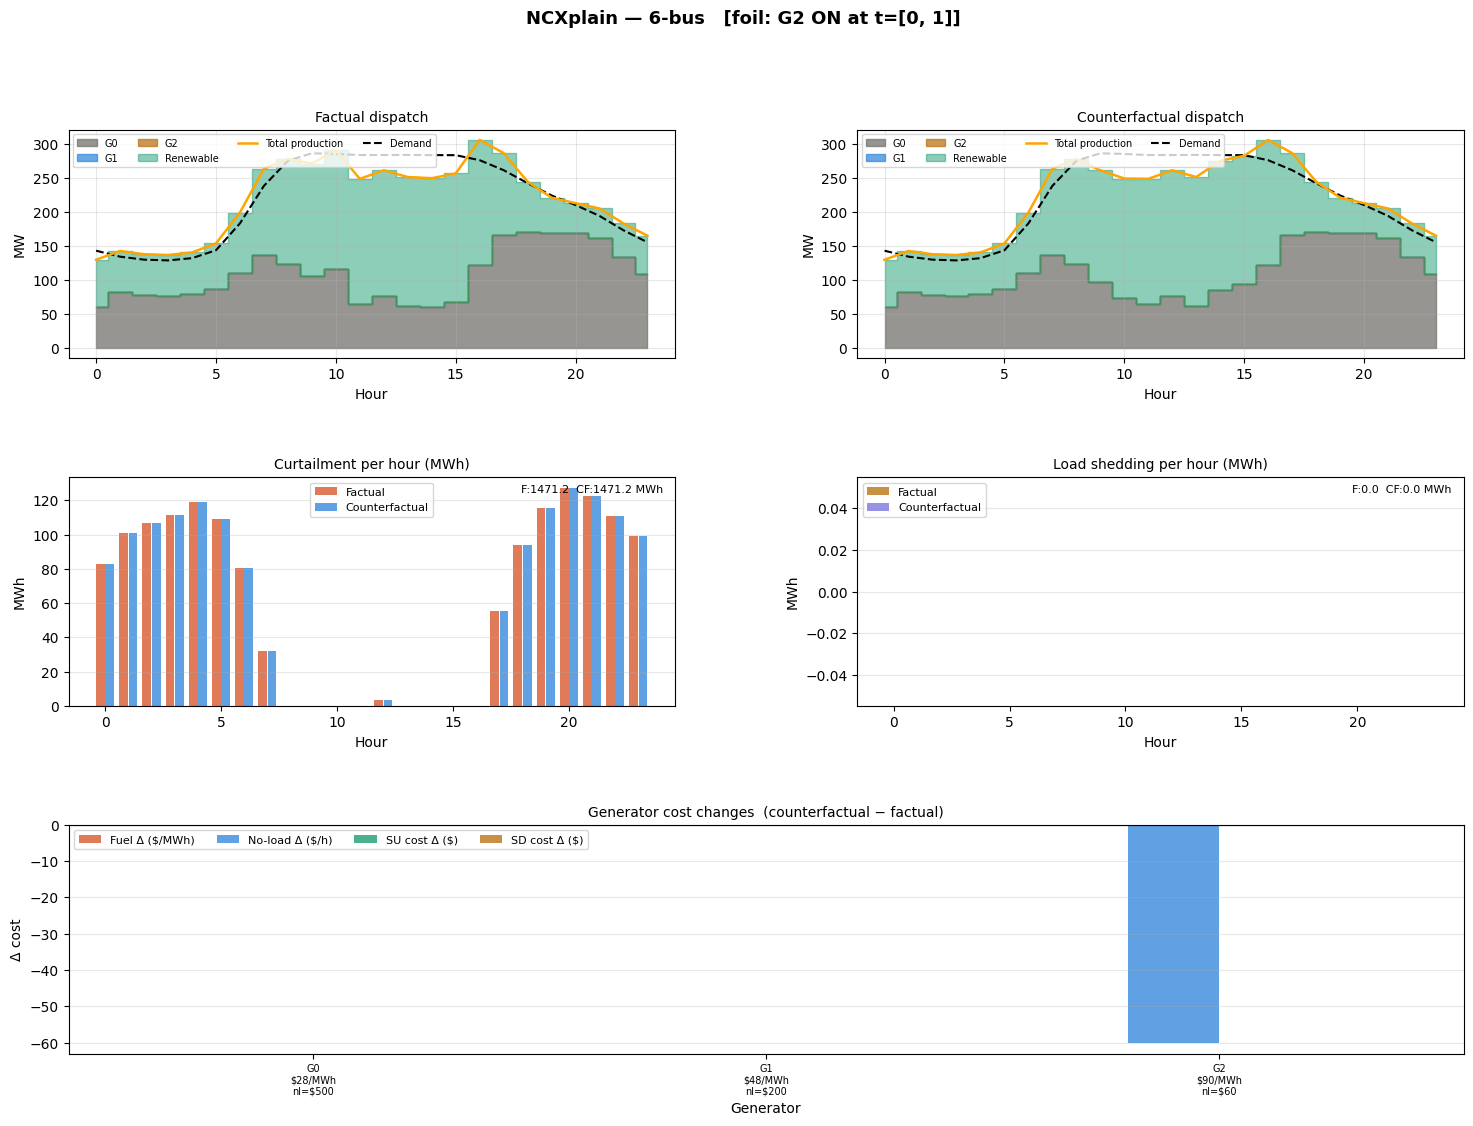

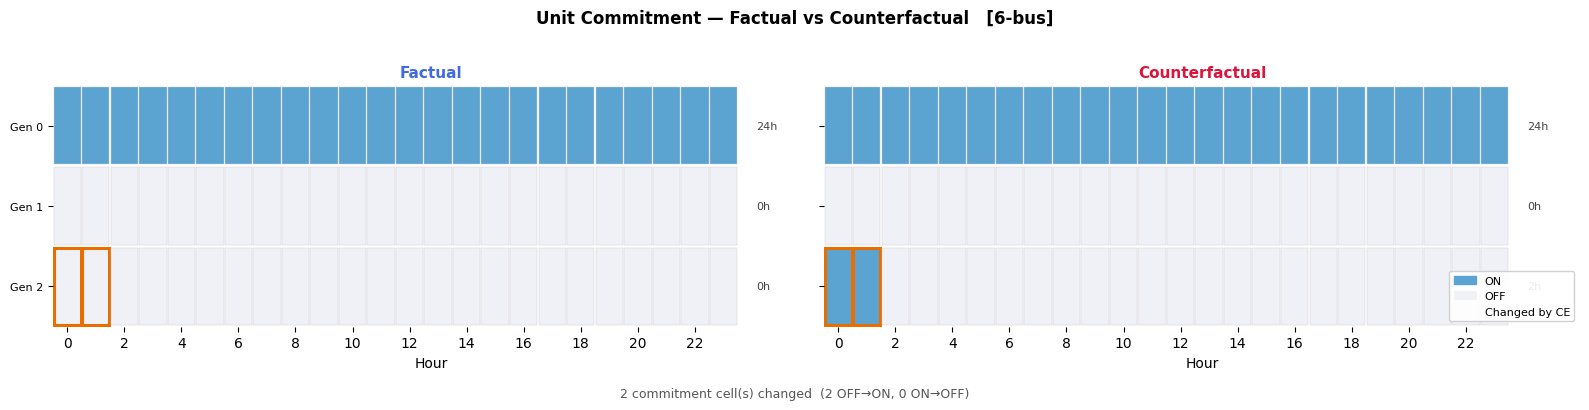


6-bus — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    2       90.00      0.00       60.00      -60.00        0.00        0.00

6-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


In [13]:
plot_ncxplain_results(
    DATA_6, out_6, label='6-bus',
    foil_g=best_g_6, foil_times=best_times_6, foil_type=best_type_6,
)

if str(out_6.get('status','')).upper() == 'OPTIMAL':
    print(f'\n6-bus — output keys: {list(out_6.keys())}')


### 3.2 · 14-bus

In [14]:
assert foil_14 is not None, "Run Section 2 first"

out_14 = run_ncxplain_uc(
    data=DATA_14,
    window_size=int(DATA_14.T),
    per_bus_neutrality=True,
    foil_fn=foil_14,
    mutables={"gen_costs"},
    bounds={"fuel":    (0, 500),
             "no_load": (0, 5000),
             "su":      (0, 100_000),
             "sd":      (0, 100_000)},
    weights={"gen_costs": 1.0},
    verbose=True,
)
print(f"\n14-bus  status: {out_14['status']}")


[NCX it=01] gap=5.82077e-11 | stop_tol=0.5 | MP_obj=50.000000000009024

14-bus  status: OPTIMAL


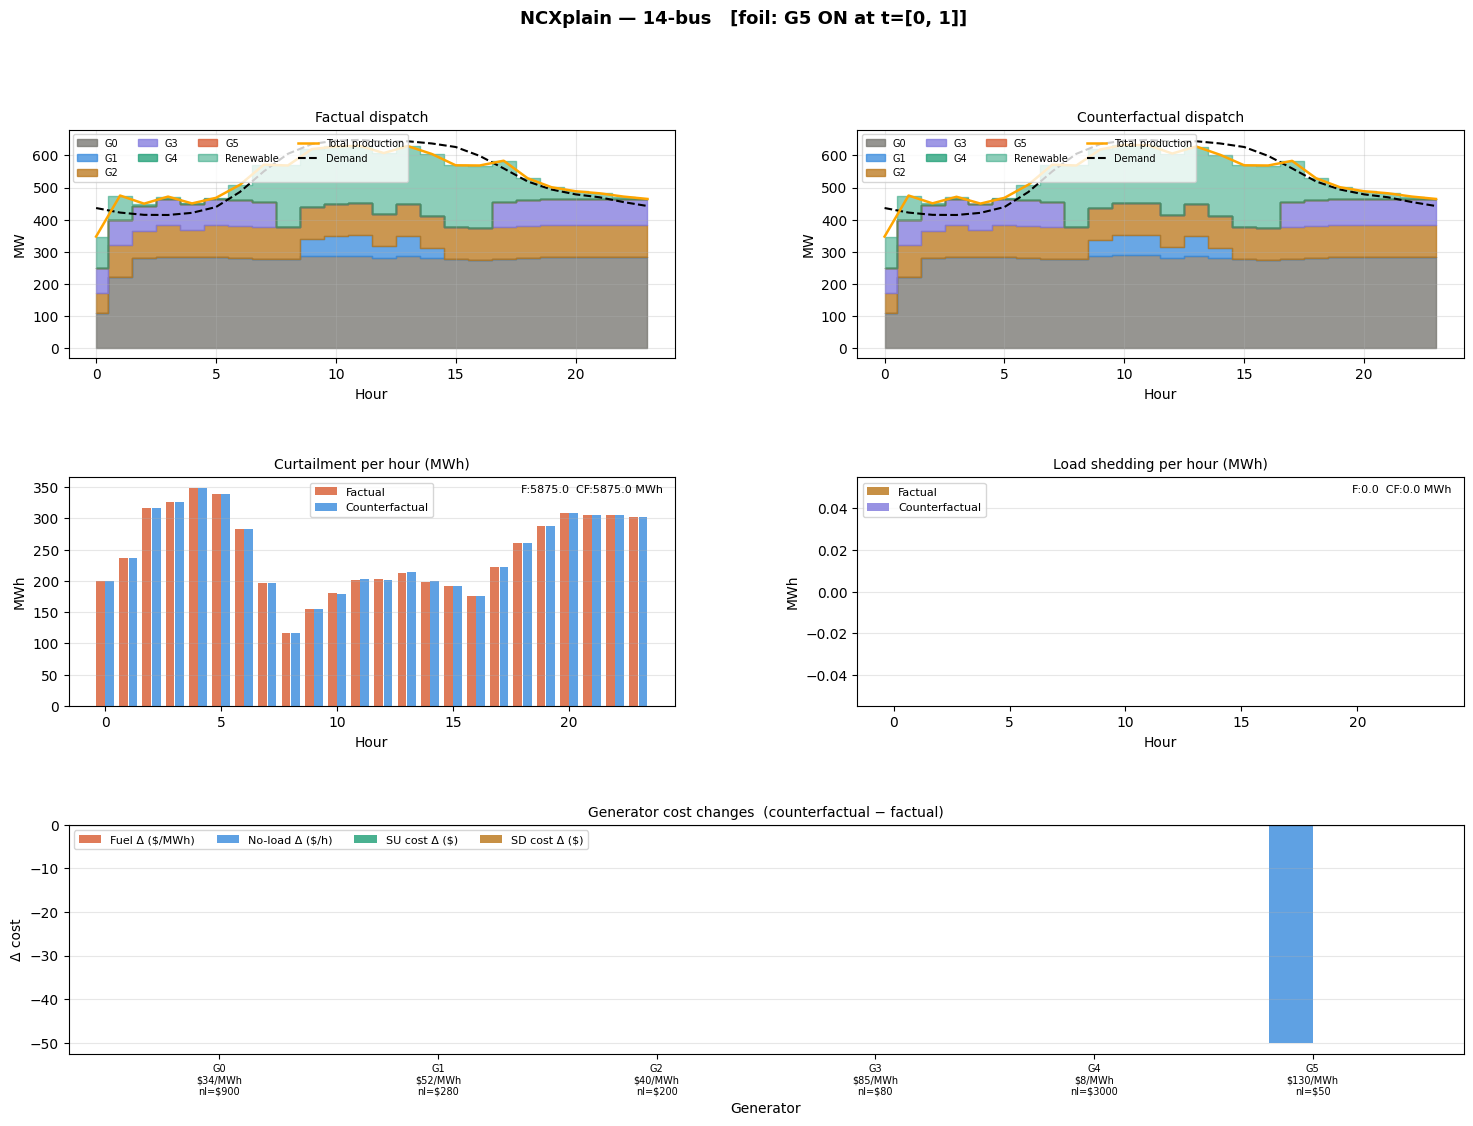

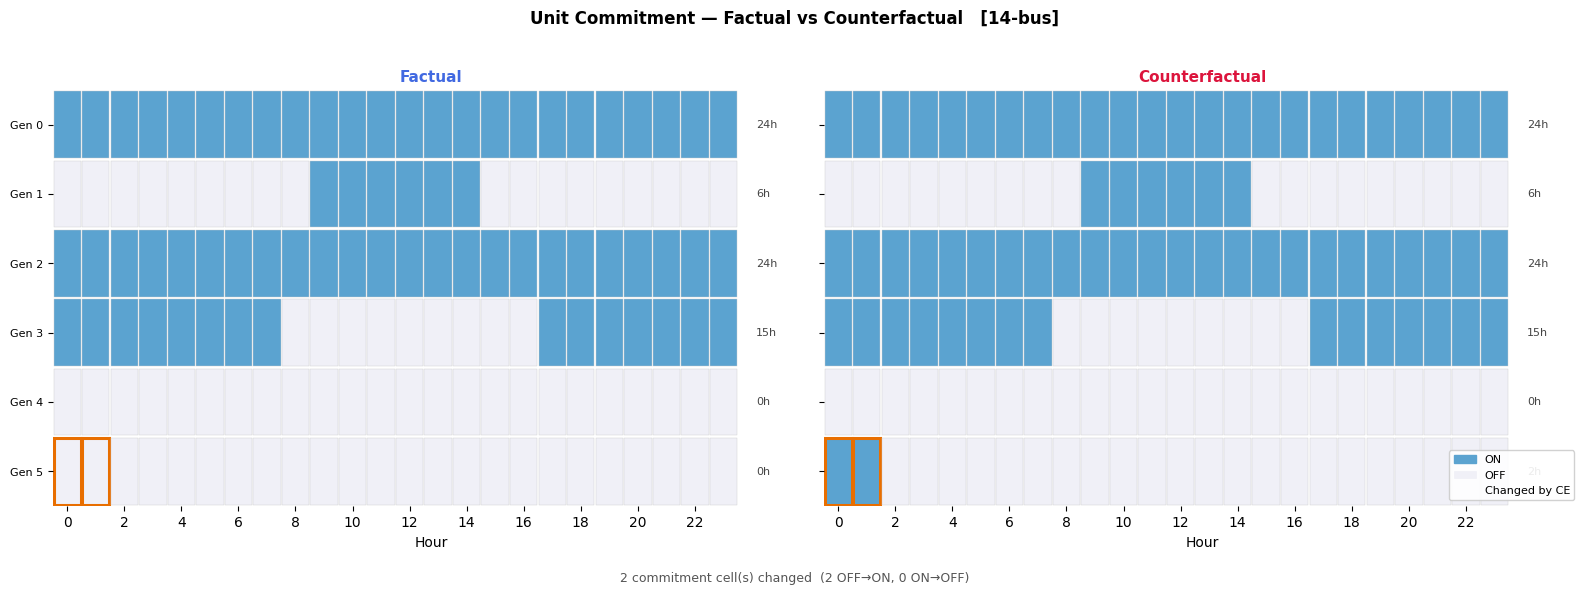


14-bus — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    5      130.00      0.00       50.00      -50.00        0.00        0.00

14-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


In [15]:
plot_ncxplain_results(
    DATA_14, out_14, label='14-bus',
    foil_g=best_g_14, foil_times=best_times_14, foil_type=best_type_14,
)

if str(out_14.get('status','')).upper() == 'OPTIMAL':
    print(f'\n14-bus — output keys: {list(out_14.keys())}')


### 3.3 · 39-bus

In [16]:
assert foil_39 is not None, "Run Section 2 first"

out_39 = run_ncxplain_uc(
    data=DATA_39,
    window_size=int(DATA_39.T),
    per_bus_neutrality=True,
    foil_fn=foil_39,
    mutables={"gen_costs"},
    bounds={"fuel":    (0, 500),
             "no_load": (0, 5000),
             "su":      (0, 100_000),
             "sd":      (0, 100_000)},
    weights={"gen_costs": 1.0},
    verbose=True,
)
print(f"\n39-bus  status: {out_39['status']}")


[NCX it=01] gap=-7.27596e-11 | stop_tol=0.127 | MP_obj=175250.0

39-bus  status: OPTIMAL


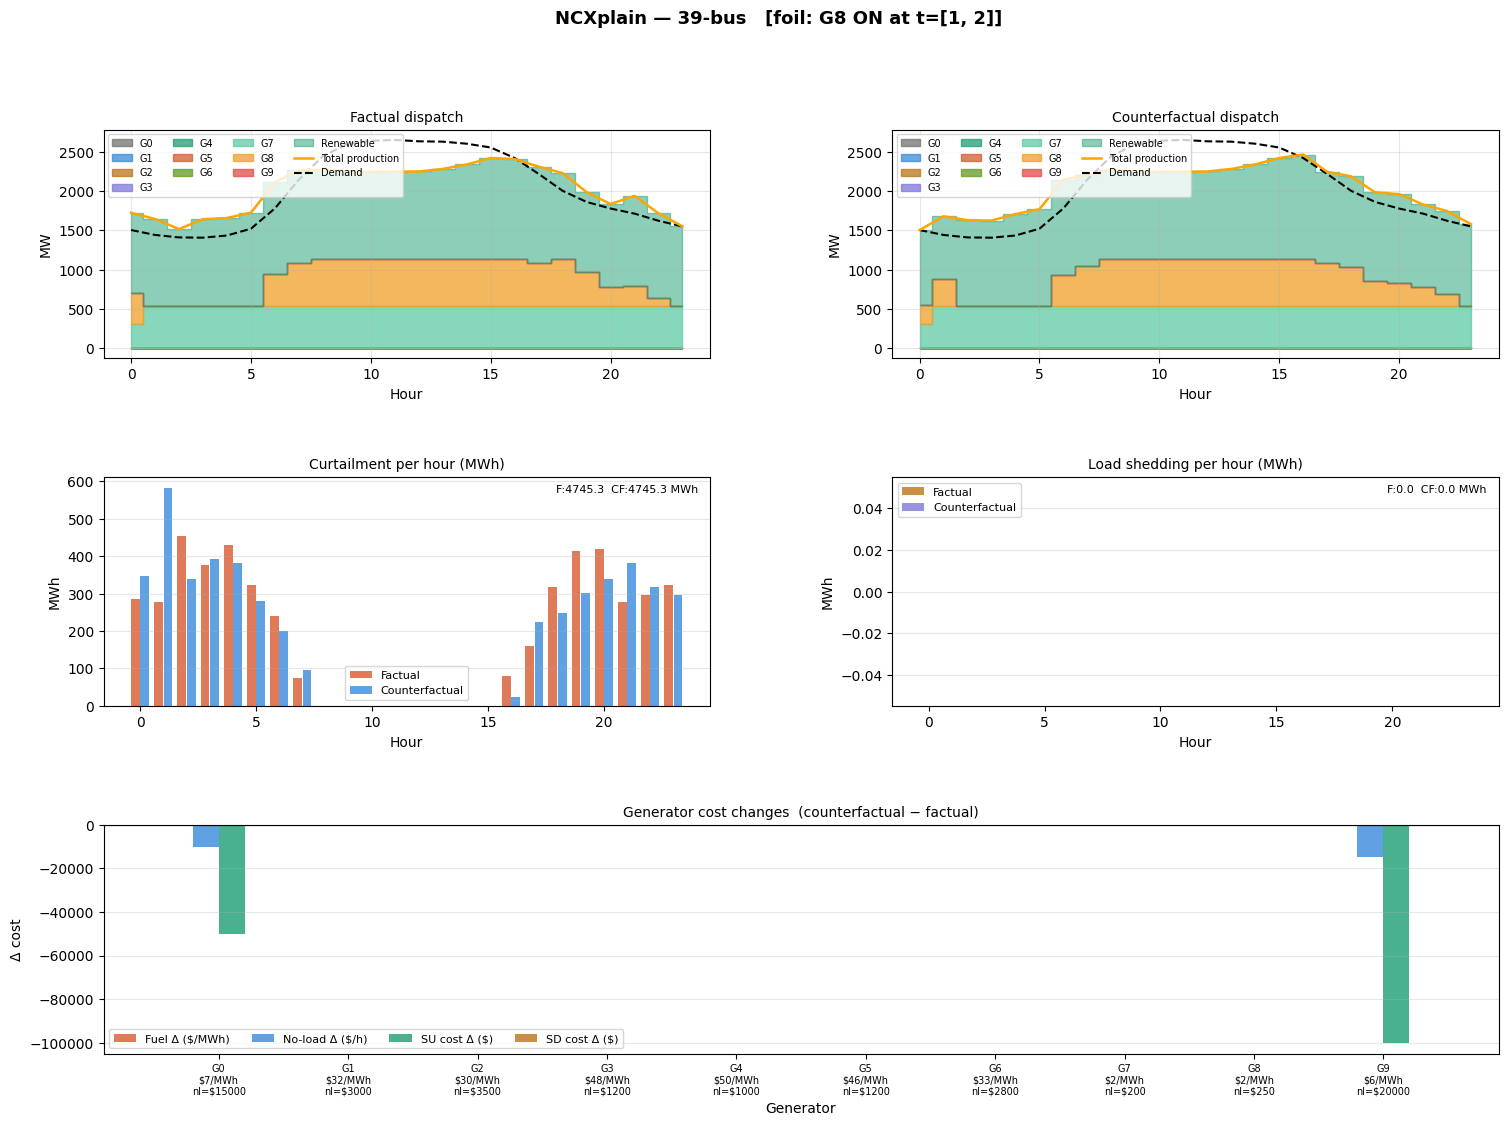

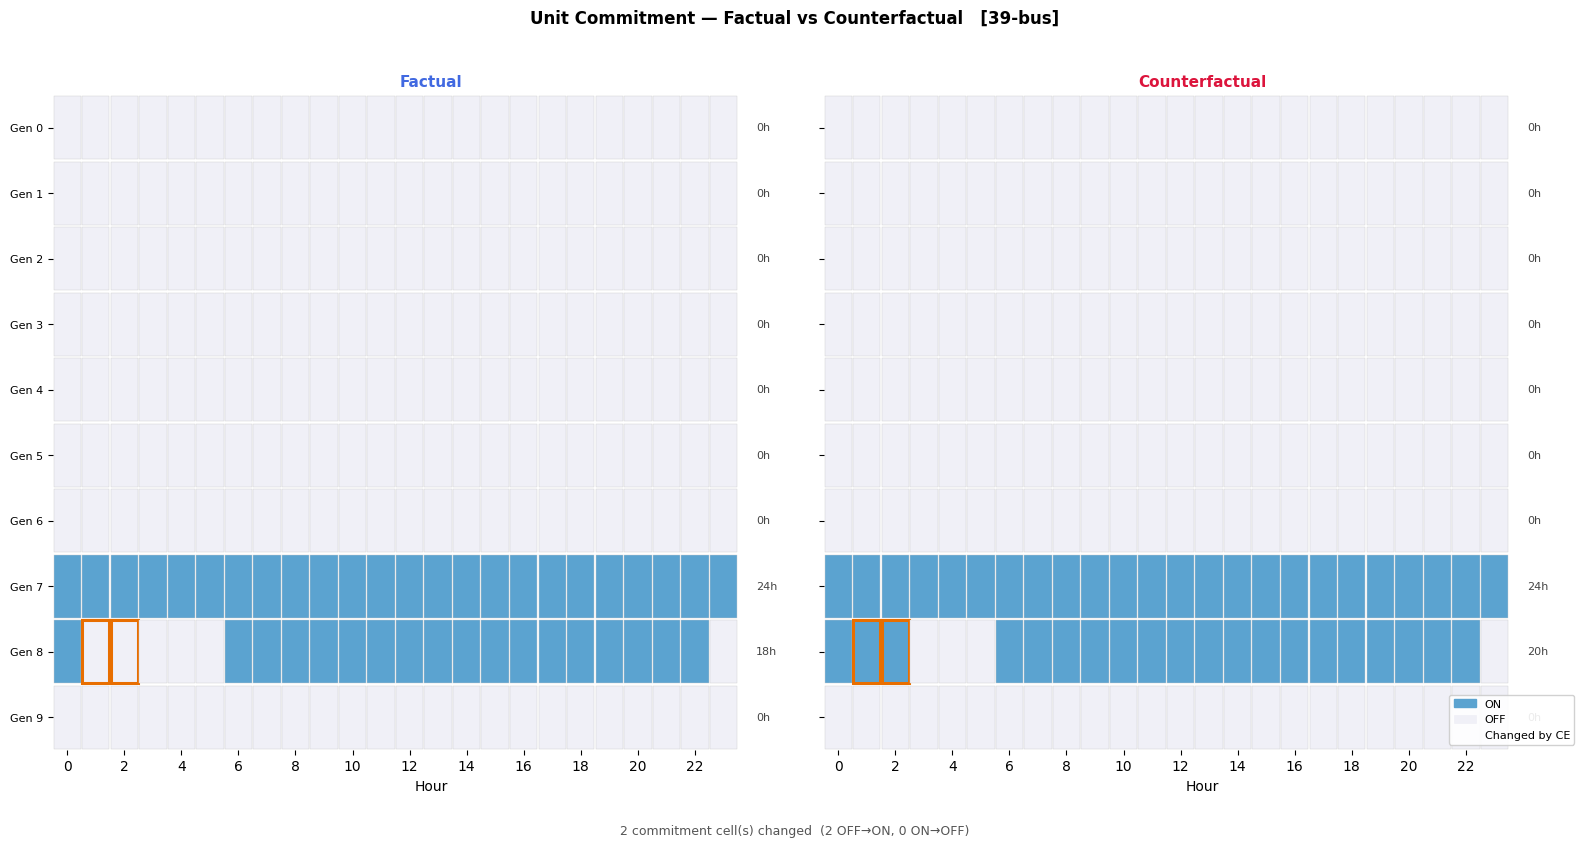


39-bus — cost changes:
    G   orig_fuel     Δfuel   orig_nlod    Δno-load         ΔSU         ΔSD
    0        7.00      0.00    15000.00   -10000.00   -50000.00        0.00
    8        2.50      0.00      250.00     -250.00        0.00        0.00
    9        6.50      0.00    20000.00   -15000.00  -100000.00        0.00

39-bus — output keys: ['status', 'iters', 'mutables', 'bounds', 'weights', 'z_foil', 'z_opt', 'dTx_foil', 'dTx_opt', 'gap', 'stop_tol', 'mp_details', 'sol_factual', 'sol_foil', 'sol_opt', 'pi_plus_new', 'pi_minus_new', 'curt_cost_new', 'fuel_cost_new', 'no_load_cost_new', 'su_cost_new', 'sd_cost_new']


In [17]:
plot_ncxplain_results(
    DATA_39, out_39, label='39-bus',
    foil_g=best_g_39, foil_times=best_times_39, foil_type=best_type_39,
)

if str(out_39.get('status','')).upper() == 'OPTIMAL':
    print(f'\n39-bus — output keys: {list(out_39.keys())}')


---
## Section 4 · Cross-grid comparison


In [18]:
print(f"{'Grid':<10} {'Foil':>22} {'Gap ($)':>12} {'Status':>12}")
print(chr(9472)*60)
for lbl, cands, out in [
    ("6-bus",  candidates_6,  out_6),
    ("14-bus", candidates_14, out_14),
    ("39-bus", candidates_39, out_39),
]:
    foil_str = f"G{cands[0][1]} t={cands[0][2]}" if cands else "none"
    gap_str  = f"{cands[0][0]:.0f}" if cands else "—"
    status   = out.get("status","—") if out else "—"
    print(f"{lbl:<10} {foil_str:>22} {gap_str:>12} {status:>12}")


Grid                         Foil      Gap ($)       Status
────────────────────────────────────────────────────────────
6-bus                 G2 t=[0, 1]          480      OPTIMAL
14-bus                G5 t=[0, 1]          340      OPTIMAL
39-bus                G8 t=[1, 2]          500      OPTIMAL
